# Experiments Guide

## 0. Colab Setup

In [ ]:
!git clone -b dev-CREMAD https://github.com/luigiaceto/explainable-models-for-speech-analysis.git
%cd explainable-models-for-speech-analysis
%pip install -r requirements-colab.txt

## 1. Project Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.audio_features import pooled_feature_dim
from src.utils.naming import (
    blackbox_penultimate_feature_dir_name,
    blackbox_run_dir_name,
    model_name_to_slug,
    pooled_feature_dir_name,
    prototype_clustering_run_dir_name
)

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / "crema_d"
AUDIO_DIR = RAW_DIR / "AudioWAV"

# (model_name, dimension_of_the_original_vectors_generated_by_the_model)
FEATURE_EXTRACTOR = ("microsoft/wavlm-large", 1024)

FEATURE_EXTRACTOR_NAME, ENCODER_EMBEDDING_DIM = FEATURE_EXTRACTOR
FEATURE_EXTRACTOR_ID = model_name_to_slug(FEATURE_EXTRACTOR_NAME)
FEATURE_POOLING = "mean_std"
FEATURE_DIM = pooled_feature_dim(ENCODER_EMBEDDING_DIM, FEATURE_POOLING)

FEATURE_DIR = DATA_DIR / "features" / pooled_feature_dir_name(FEATURE_EXTRACTOR_NAME, FEATURE_POOLING)
BLACK_BOX_CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / blackbox_run_dir_name(FEATURE_EXTRACTOR_NAME)
BLACK_BOX_REPORT_DIR = PROJECT_ROOT / "reports" / blackbox_run_dir_name(FEATURE_EXTRACTOR_NAME)
BLACK_BOX_EMBEDDING_DIR = DATA_DIR / "features" / blackbox_penultimate_feature_dir_name(FEATURE_EXTRACTOR_NAME)

FEATURE_EXTRACTION_BATCH_SIZE = 8
FEATURE_EXTRACTION_NUM_WORKERS = 0
RANDOM_STATE = 42

PROTOTYPE_CLUSTERING_CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / prototype_clustering_run_dir_name(FEATURE_EXTRACTOR_NAME)
PROTOTYPE_CLUSTERING_REPORT_DIR = PROJECT_ROOT / "reports" / prototype_clustering_run_dir_name(FEATURE_EXTRACTOR_NAME)

PROJECT_ROOT

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis')

## 2. Download CREMA-D

In [3]:
from src.preprocessing.download_crema_d import download_crema_d

metadata = download_crema_d(
    output_dir=RAW_DIR,
    overwrite=False
)

metadata.head(n=10)

,file_name,actor_id,sentence_code,sentence,emotion_code,emotion,label,intensity_code,intensity,audio_path
0,1001_DFA_ANG_XX.wav,1001,DFA,Don't forget a jacket,ANG,anger,0,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
1,1001_DFA_DIS_XX.wav,1001,DFA,Don't forget a jacket,DIS,disgust,1,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
2,1001_DFA_FEA_XX.wav,1001,DFA,Don't forget a jacket,FEA,fear,2,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
3,1001_DFA_HAP_XX.wav,1001,DFA,Don't forget a jacket,HAP,happy,3,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
4,1001_DFA_NEU_XX.wav,1001,DFA,Don't forget a jacket,NEU,neutral,4,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
5,1001_DFA_SAD_XX.wav,1001,DFA,Don't forget a jacket,SAD,sad,5,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
6,1001_IEO_ANG_HI.wav,1001,IEO,It's eleven o'clock,ANG,anger,0,HI,high,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
7,1001_IEO_ANG_LO.wav,1001,IEO,It's eleven o'clock,ANG,anger,0,LO,low,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
8,1001_IEO_ANG_MD.wav,1001,IEO,It's eleven o'clock,ANG,anger,0,MD,medium,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
9,1001_IEO_DIS_HI.wav,1001,IEO,It's eleven o'clock,DIS,disgust,1,HI,high,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...


## 3. Dataset Statistics

In [4]:
from src.data.crema_d import print_dataset_statistics

print_dataset_statistics(metadata)

Total samples: 7442
Actors: 91
Sentence prompts: 12

Samples per emotion:
emotion  sample_count  percentage
  anger          1271   17.078742
disgust          1271   17.078742
   fear          1271   17.078742
  happy          1271   17.078742
neutral          1087   14.606289
    sad          1271   17.078742


## 4. Extract Frozen Audio Encoder Features

In [ ]:
from src.preprocessing.extract_audio_features import extract_audio_features

feature_paths = extract_audio_features(
    metadata_csv=RAW_DIR / "metadata.csv",
    audio_dir=AUDIO_DIR,
    output_dir=FEATURE_DIR,
    model_name=FEATURE_EXTRACTOR_NAME,
    expected_encoder_embedding_dim=ENCODER_EMBEDDING_DIM,
    pooling=FEATURE_POOLING,
    batch_size=FEATURE_EXTRACTION_BATCH_SIZE,
    num_workers=FEATURE_EXTRACTION_NUM_WORKERS,
    overwrite=False
)

feature_paths

## 5. Train the Black-Box Classifier

In [5]:
from src.training.train_blackbox import TrainingConfig, train_blackbox

SPLIT_STRATEGY = "sample_stratified"
#SPLIT_STRATEGY = "speaker_independent" # each split has different voice actors
LAYER_DIMS = (256, 128)

training_config = TrainingConfig(
    input_dim=FEATURE_DIM,
    feature_extractor_name=FEATURE_EXTRACTOR_NAME,
    encoder_embedding_dim=ENCODER_EMBEDDING_DIM,
    pooling=FEATURE_POOLING,
    hidden_dims=LAYER_DIMS,
    batch_size=64,
    epochs=100,
    dropout=0.25,
    learning_rate=2e-4,
    weight_decay=5e-4,
    split_strategy=SPLIT_STRATEGY,
    speaker_column="actor_id",
    early_stopping_patience=15,
    #lr_scheduler=None, # by default the scheduler is active. Need to set it explicitly to None if we wanna turn it off
    scheduler_patience=6,
    random_state=RANDOM_STATE
)

training_results = train_blackbox(
    feature_dir=FEATURE_DIR,
    output_dir=BLACK_BOX_CHECKPOINT_DIR,
    config=training_config
)

/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/src/data/crema_d.py:175: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self.labels = torch.as_tensor(


Training black-box model:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 001 | train loss 1.6137, acc 0.3248, macro F1 0.3066 | val loss 1.4134, acc 0.4848, macro F1 0.4345, weighted F1 0.4315 | lr 2.00e-04 | best
Epoch 002 | train loss 1.3741, acc 0.4554, macro F1 0.4390 | val loss 1.3099, acc 0.4875, macro F1 0.4601, weighted F1 0.4572 | lr 2.00e-04 | best
Epoch 003 | train loss 1.2189, acc 0.5325, macro F1 0.5228 | val loss 1.0902, acc 0.5905, macro F1 0.5698, weighted F1 0.5661 | lr 2.00e-04 | best
Epoch 004 | train loss 1.1056, acc 0.5723, macro F1 0.5671 | val loss 1.1005, acc 0.5699, macro F1 0.5379, weighted F1 0.5345 | lr 2.00e-04 | patience 1/15
Epoch 005 | train loss 1.0468, acc 0.6013, macro F1 0.5982 | val loss 1.0131, acc 0.6344, macro F1 0.6443, weighted F1 0.6409 | lr 2.00e-04 | best
Epoch 006 | train loss 1.0035, acc 0.6118, macro F1 0.6094 | val loss 0.9709, acc 0.6452, macro F1 0.6453, weighted F1 0.6413 | lr 2.00e-04 | best
Epoch 007 | train loss 0.9421, acc 0.6431, macro F1 0.6417 | val loss 0.9436, acc 0.6434, macro F1 0.6410, we

## 6. Evaluate the Black-Box Classifier

In [6]:
from src.evaluation.evaluate_blackbox import evaluate_blackbox
from src.evaluation.metrics import print_classification_metrics

test_metrics = evaluate_blackbox(
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    feature_dir=FEATURE_DIR,
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split="test",
    output_dir=BLACK_BOX_REPORT_DIR
)

print_classification_metrics(test_metrics)

Accuracy:    0.7690
Macro F1:    0.7699
Weighted F1: 0.7680

Classification report:
emotion precision recall f1_score  support
  anger    0.8505 0.8639   0.8571      191
disgust    0.7651 0.6649   0.7115      191
   fear    0.7380 0.7263   0.7321      190
  happy    0.7629 0.7749   0.7688      191
neutral    0.8136 0.8834   0.8471      163
    sad    0.6884 0.7173   0.7026      191


In [ ]:
from IPython.display import Image, display

confusion_matrix_path = BLACK_BOX_REPORT_DIR / "test_confusion_matrix.png"
if confusion_matrix_path.exists():
    display(Image(filename=str(confusion_matrix_path)))

## 7. Visualize Embedding Spaces

Project the pooled audio encoder features and the trained black-box penultimate representations to two PCA dimensions.


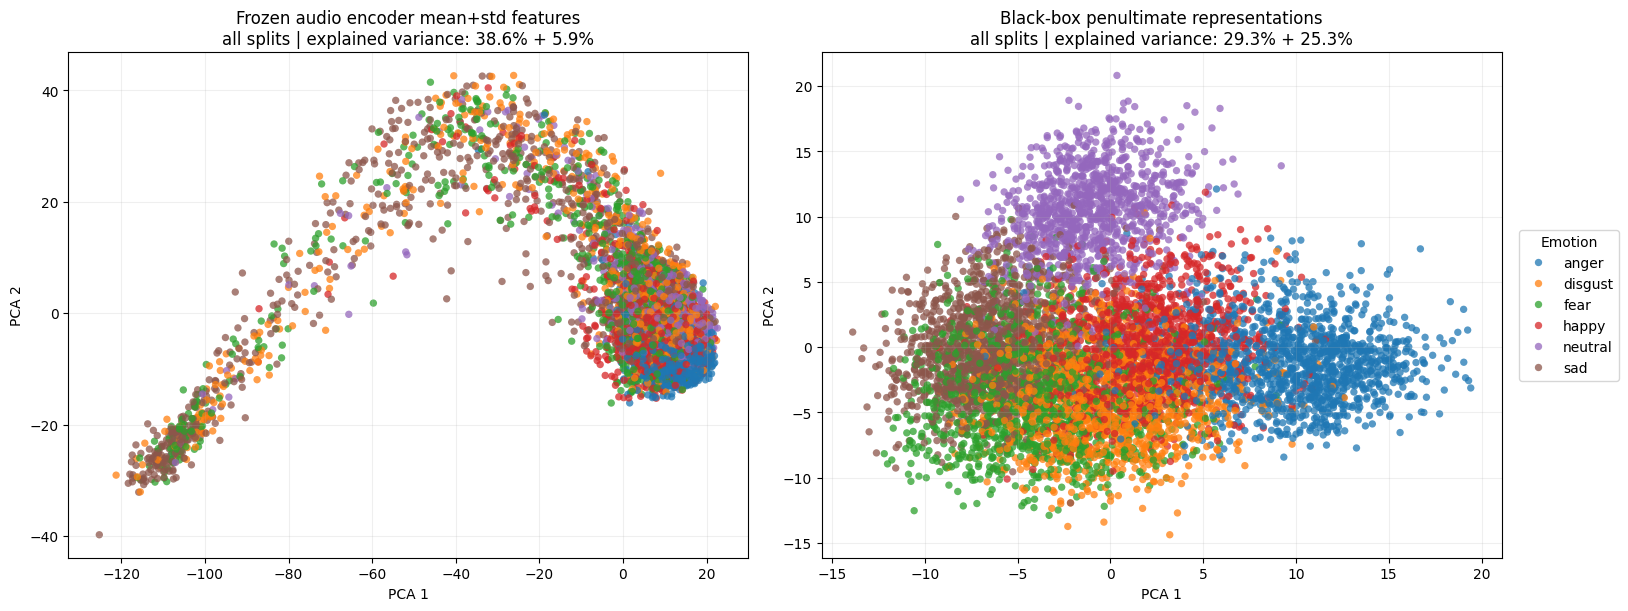

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/reports/blackbox_wavlm_large/all_embedding_pca.png')

In [7]:
from src.utils.visualize import plot_blackbox_embedding_pca

split_to_visualize = "all"

embedding_pca_result = plot_blackbox_embedding_pca(
    feature_dir=FEATURE_DIR,
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split=split_to_visualize,
    output_path=BLACK_BOX_REPORT_DIR / f"{split_to_visualize}_embedding_pca.png",
    random_state=RANDOM_STATE
)

embedding_pca_result["output_path"]

## 8. Extract Black-Box Penultimate Embeddings

Extract the representation before the final black-box classification layer and save its L2-normalized version.

In [8]:
from src.preprocessing.extract_blackbox_embeddings import extract_blackbox_penultimate_embeddings_l2

blackbox_embedding_paths = extract_blackbox_penultimate_embeddings_l2(
    feature_dir=FEATURE_DIR,
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    output_dir=BLACK_BOX_EMBEDDING_DIR,
    batch_size=256,
    overwrite=False
)

blackbox_embedding_paths

{'features': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_wavlm_large_penultimate_l2/features.npy'),
 'metadata': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_wavlm_large_penultimate_l2/metadata.csv'),
 'config': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_wavlm_large_penultimate_l2/embedding_config.json')}

## 9. Prototype Clustering Grid Search

Fit K-means on the training split only, with K clusters per emotion. Each centroid is mapped to the nearest real training sample of the same emotion, and these real prototypes are used for classification. Select K and top-N on the validation split.

In [9]:
from src.training.train_prototype_clustering import (
    PrototypeClusteringTrainingConfig,
    train_prototype_clustering
)

prototype_training_config = PrototypeClusteringTrainingConfig(
    embedding_dim=LAYER_DIMS[1],
    cluster_counts=(1, 2, 3, 4, 5, 6),
    monitor_metric="macro_f1",
    random_state=RANDOM_STATE
)

prototype_training_results = train_prototype_clustering(
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    output_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    config=prototype_training_config
)

K=01, all prototypes=06 | val acc 0.7401, macro F1 0.7414, weighted F1 0.7387
K=02, all prototypes=12 | val acc 0.7312, macro F1 0.7299, weighted F1 0.7266
K=03, all prototypes=18 | val acc 0.7473, macro F1 0.7462, weighted F1 0.7436
K=04, all prototypes=24 | val acc 0.7375, macro F1 0.7348, weighted F1 0.7319
K=05, all prototypes=30 | val acc 0.7339, macro F1 0.7327, weighted F1 0.7299
K=06, all prototypes=36 | val acc 0.7410, macro F1 0.7404, weighted F1 0.7376

Best prototype clustering configuration
  K:           3
  Prototypes:  18 used for voting
  Validation:  accuracy 0.7473, macro F1 0.7462, weighted F1 0.7436


## 10. Evaluate Prototype Clustering Classifier

In [10]:
from src.evaluation.evaluate_prototype_clustering import evaluate_prototype_clustering
from src.evaluation.metrics import print_classification_metrics

prototype_test_metrics = evaluate_prototype_clustering(
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    split="test",
    output_dir=PROTOTYPE_CLUSTERING_REPORT_DIR
)

print_classification_metrics(prototype_test_metrics)

Accuracy:    0.7449
Macro F1:    0.7442
Weighted F1: 0.7419

Classification report:
emotion precision recall f1_score  support
  anger    0.8058 0.8691   0.8363      191
disgust    0.8310 0.6178   0.7087      191
   fear    0.7333 0.5789   0.6471      190
  happy    0.7409 0.7487   0.7448      191
neutral    0.7849 0.8957   0.8367      163
    sad    0.6208 0.7801   0.6914      191


## 11. Evaluate Prototype Surrogate Fidelity

Measure how often the clustering surrogate matches the black-box predictions on the test split.

In [11]:
from src.explainability.surrogate_fidelity import print_clustering_surrogate_fidelity_accuracy

surrogate_fidelity_metrics = print_clustering_surrogate_fidelity_accuracy(
    blackbox_checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    feature_dir=FEATURE_DIR,
    prototype_model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split="test"
)

Accuracy against black-box predictions: 0.9105 (1017/1117)


## 12. Visualize Prototype Embedding Space

Project the saved L2-normalized black-box embeddings to two PCA dimensions and highlight the prototypes of each emotion.

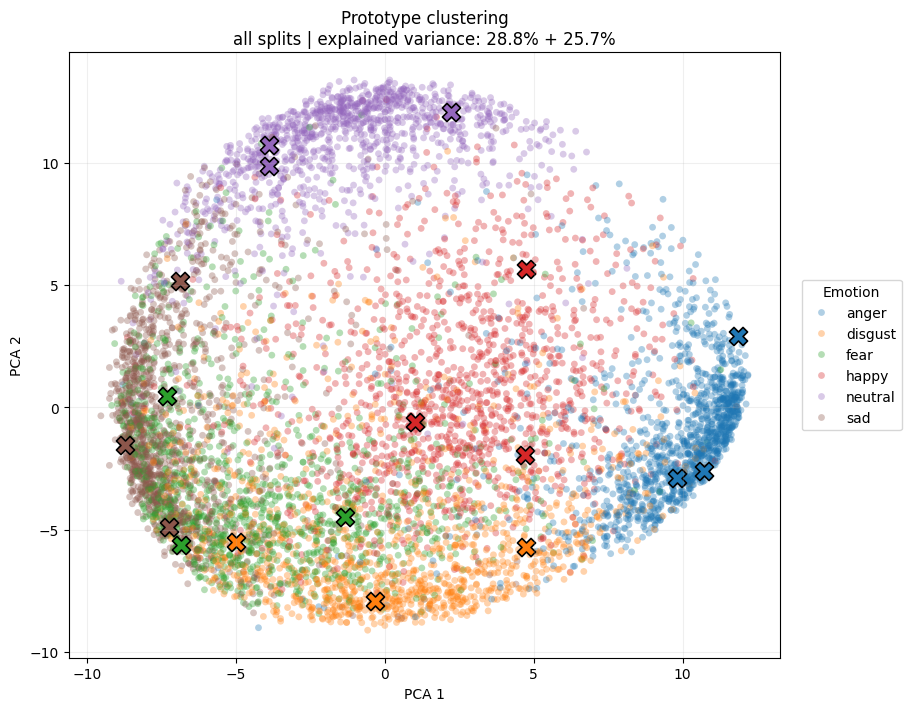

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/reports/prototype_clustering_wavlm_large/all_prototype_embedding_pca.png')

In [12]:
from src.utils.visualize import plot_prototype_embedding_pca

prototype_pca_result = plot_prototype_embedding_pca(
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    split="all",
    output_path=PROTOTYPE_CLUSTERING_REPORT_DIR / "all_prototype_embedding_pca.png",
    random_state=RANDOM_STATE
)

prototype_pca_result["output_path"]

## 13. Explanation By Example - Inspect Prototype Neighbors of a Test Sample

In [3]:
import pandas as pd
from src.explainability.prototype_neighbors import (
    explain_sample_by_filename,
    print_prototype_explanation
)

# Set a CREMA-D file name here, or leave it as None to use the first test sample.
SAMPLE_TO_EXPLAIN = "1003_IEO_NEU_XX.wav"

prototype_explanation = explain_sample_by_filename(
    embedding_metadata=pd.read_csv(BLACK_BOX_EMBEDDING_DIR / "metadata.csv"),
    sample_to_explain=SAMPLE_TO_EXPLAIN,
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR
)

print_prototype_explanation(prototype_explanation)

Sample:    1003_IEO_NEU_XX.wav
True:      neutral
Predicted: neutral

Class scores:
    anger: 0.9458
  disgust: 0.4314
     fear: 0.7564
    happy: 1.1182
  neutral: 2.7551
      sad: 1.3338

All 18 voting prototypes, sorted by similarity:
  #01 neutral | sim 0.9579 | 1063_IEO_NEU_XX.wav
  #02 neutral | sim 0.9290 | 1041_WSI_NEU_XX.wav
  #03 neutral | sim 0.8683 | 1007_IWW_NEU_XX.wav
  #04     sad | sim 0.7295 | 1076_TAI_SAD_XX.wav
  #05   happy | sim 0.5675 | 1019_IWL_HAP_XX.wav
  #06    fear | sim 0.4954 | 1012_IEO_FEA_LO.wav
  #07   anger | sim 0.4809 | 1011_IWL_ANG_XX.wav
  #08     sad | sim 0.3826 | 1030_IWW_SAD_XX.wav
  #09   happy | sim 0.2908 | 1046_ITH_HAP_XX.wav
  #10   happy | sim 0.2599 | 1047_ITS_HAP_XX.wav
  #11   anger | sim 0.2492 | 1079_ITH_ANG_XX.wav
  #12 disgust | sim 0.2372 | 1010_DFA_DIS_XX.wav
  #13     sad | sim 0.2216 | 1037_IWL_SAD_XX.wav
  #14   anger | sim 0.2157 | 1002_WSI_ANG_XX.wav
  #15    fear | sim 0.1607 | 1014_ITS_FEA_XX.wav
  #16 disgust | sim 0.12

We can listen to the test sample and its nearest prototypes (medoids).

In [14]:
from IPython.display import Audio, display, Markdown

display(Markdown(f"### Sample: `{SAMPLE_TO_EXPLAIN}`"))
display(Audio(filename=str(AUDIO_DIR / SAMPLE_TO_EXPLAIN)))

display(Markdown("### Top prototypes"))
for prototype in prototype_explanation["top_prototypes"]:
    prototype_file = prototype.get("prototype_file_name")

    display(Markdown(
        f"**#{prototype['rank']} | {prototype['prototype_emotion']} | "
        f"similarity: {prototype['similarity']:.4f}**  \n"
        f"`{prototype_file}`"
    ))
    display(Audio(filename=str(AUDIO_DIR / prototype_file)))

### Sample: `1014_IWL_DIS_XX.wav`

### Top prototypes

**#1 | disgust | similarity: 0.9397**  
`1010_DFA_DIS_XX.wav`

**#2 | sad | similarity: 0.8466**  
`1037_IWL_SAD_XX.wav`

**#3 | fear | similarity: 0.8372**  
`1014_ITS_FEA_XX.wav`

...

**#14 | anger | similarity: 0.3147**  
`1079_ITH_ANG_XX.wav`

**#15 | neutral | similarity: 0.3059**  
`1041_WSI_NEU_XX.wav`

**#16 | anger | similarity: 0.3018**  
`1002_WSI_ANG_XX.wav`

**#17 | anger | similarity: 0.1719**  
`1011_IWL_ANG_XX.wav`

**#18 | neutral | similarity: 0.1582**  
`1063_IEO_NEU_XX.wav`